# SVM

## Linear SVM

In [287]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_circles, make_moons, load_breast_cancer
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

In [288]:
def plot_decision_boundary(clf, X, y, scaler=None, ax=None, levels=[0], **contour_kwargs):
    """
    Рисует разделяющую границу (по умолчанию уровень 0 decision_function) для линейного классификатора.
    clf: обученный классификатор с методами decision_function, coef_, intercept_
    X, y: данные в исходном пространстве (используются для определения границ графика)
    scaler: обученный StandardScaler (или любой трансформер) - если указан, применяется к координатам сетки перед вызовом decision_function
    ax: объект matplotlib axes
    levels: уровни для contour (по умолчанию [0])
    contour_kwargs: параметры для ax.contour (цвет, толщина и т.д.)
    """
    if ax is None:
        ax = plt.gca()
    
    # Определяем границы графика по исходным данным
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    # Подготовка координат для передачи в классификатор
    grid = np.c_[xx.ravel(), yy.ravel()]
    if scaler is not None:
        grid = scaler.transform(grid)
    
    # Вычисляем decision_function
    Z = clf.decision_function(grid)
    Z = Z.reshape(xx.shape)
    
    # Рисуем контур на указанных уровнях
    ax.contour(xx, yy, Z, levels=levels, **contour_kwargs)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')
    
    return ax


In [289]:
def plot_linear_svc_decision_boundaries(svc, X, y, scaler=None, ax=None):
    if ax is None:
        ax = plt.gca()
        
    # Рисуем разделяющую границу
    plot_decision_boundary(svc, X, y, scaler=scaler, ax=ax, 
                           levels=[0], colors='k', linewidths=2, linestyles='-')

    # Рисуем границы полей (-1, 1)
    plot_decision_boundary(svc, X, y, scaler=scaler, ax=ax,
                            levels=[-1, 1], colors='k', linewidths=2, linestyles='--', alpha=0.4)
    
    # Рисуем опорные векторы
    if hasattr(svc, 'support_vectors_'):
        sv = svc.support_vectors_
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=2, label='Опорные векторы')
        ax.legend(loc='best')
        
    return ax

In [290]:
# Generate data
X, y = make_blobs(
    n_samples=200,
    centers=2,
    random_state=42,
    cluster_std=1.5,
)

# convert y to {-1, 1}
y = 2 * y - 1 #

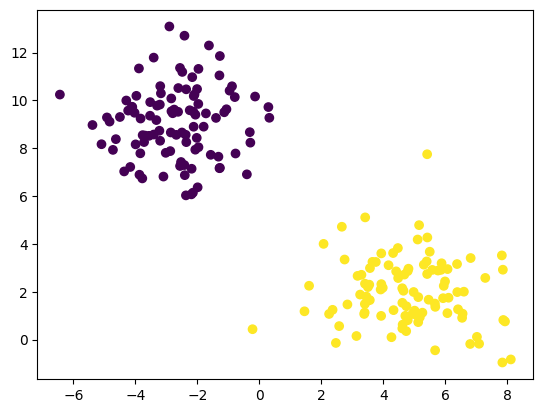

In [292]:
plt.scatter(X[:, 0], X[:, 1], c=y)

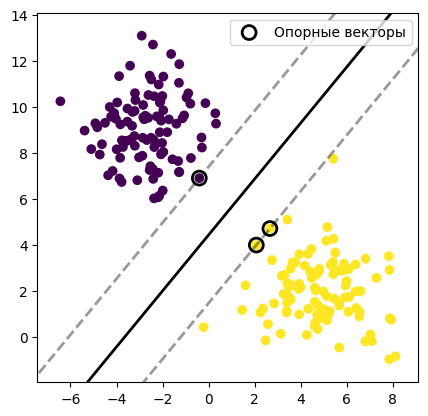

In [293]:
# SVM big C

scaler = StandardScaler()
classifier = SVC(kernel='linear', C=10, random_state=42)
pipeline = Pipeline([
    ('scaler', scaler),
    ('svm', classifier)
])

pipeline.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y)
plot_linear_svc_decision_boundaries(classifier, X, y, scaler, plt.gca())
plt.show()

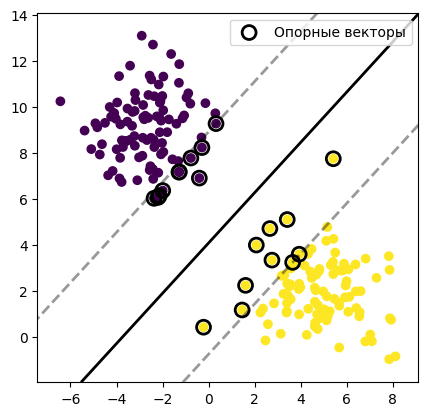

In [295]:
# SVM small C

scaler = StandardScaler()
classifier = SVC(kernel='linear', C=0.1, random_state=42)
pipeline = Pipeline([
    ('scaler', scaler),
    ('svm', classifier)
])

pipeline.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y)
plot_linear_svc_decision_boundaries(classifier, X, y, scaler, plt.gca())
plt.show()

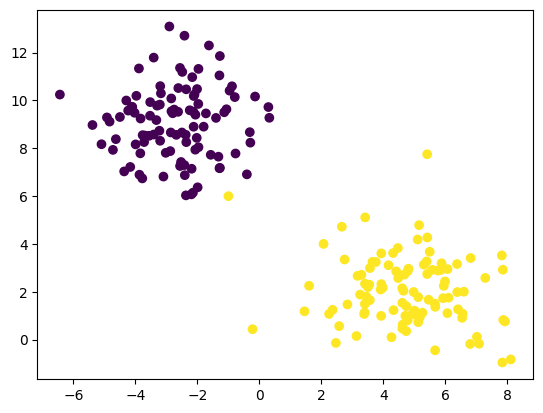

In [296]:
# add outlier

X_outlier = np.array([[-1, 6]])
y_outlier = np.array([1])
X = np.vstack([X, X_outlier])
y = np.hstack([y, y_outlier])

plt.scatter(X[:, 0], X[:, 1], c=y)

<Axes: >

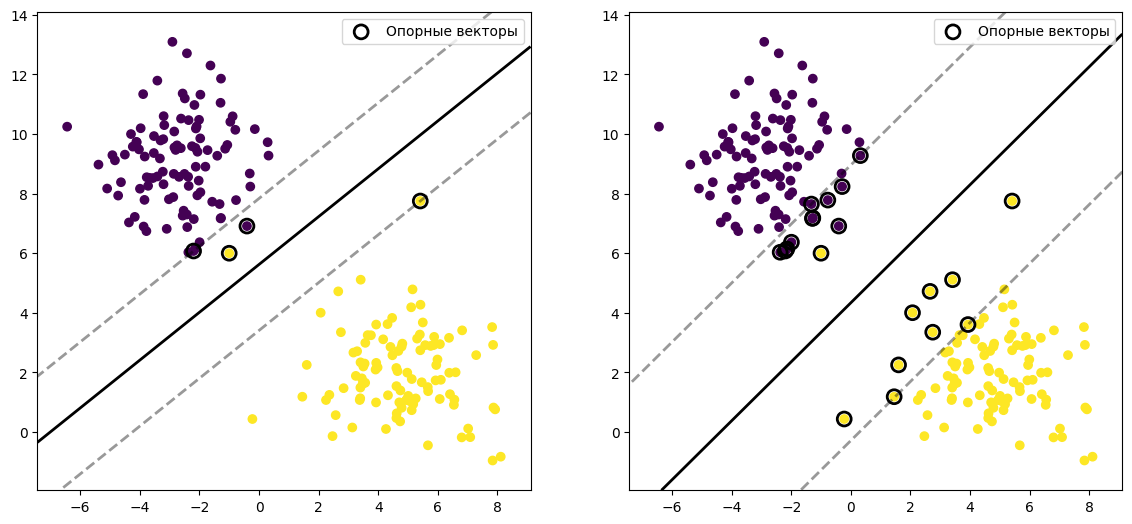

In [299]:
scaler_svc_big_c = StandardScaler()
classifier_svc_big_c = SVC(kernel='linear', C=10, random_state=42)
pipeline_svc_big_c = Pipeline([
    ('scaler', scaler_svc_big_c),
    ('svm', classifier_svc_big_c)
])

pipeline_svc_big_c.fit(X, y)


scaler_svc_small_c = StandardScaler()
classifier_svc_small_c = SVC(kernel='linear', C=0.1, random_state=42)
pipeline_svc_small_c = Pipeline([
    ('scaler', scaler_svc_small_c),
    ('svm', classifier_svc_small_c)
])

pipeline_svc_small_c.fit(X, y)


_, [ax1, ax2] = plt.subplots(1, 2, figsize=(14, 20))

ax1.scatter(X[:, 0], X[:, 1], c=y)
ax2.scatter(X[:, 0], X[:, 1], c=y)
plot_linear_svc_decision_boundaries(classifier_svc_big_c, X, y, scaler_svc_big_c, ax=ax1)
plot_linear_svc_decision_boundaries(classifier_svc_small_c, X, y, scaler_svc_small_c, ax=ax2)

[200, 86, 21, 6, 4, 3, 3]


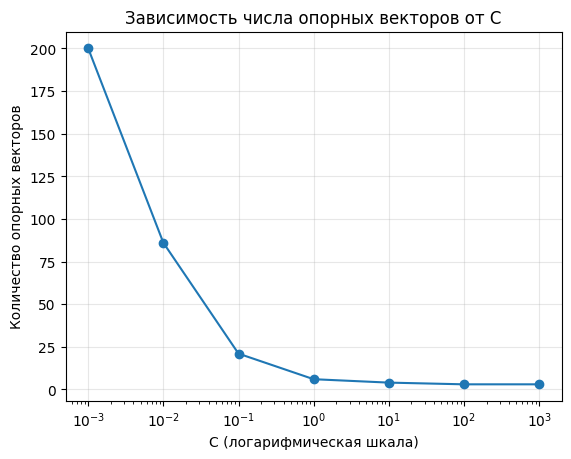

In [302]:
# Task:
#   count and plot the number of support vectors as a function of C

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
n_sv = []

for C in C_values:
    scaler = StandardScaler()
    classifier = SVC(kernel='linear', C=C, random_state=42)
    pipe = Pipeline([
        ('scaler', scaler),
        ('svc', classifier)
    ])
    pipe.fit(X, y)
    n_sv.append(len(classifier.support_vectors_))

print(n_sv)

plt.semilogx(C_values, n_sv, marker='o')
plt.xlabel('C (логарифмическая шкала)')
plt.ylabel('Количество опорных векторов')
plt.title('Зависимость числа опорных векторов от C')
plt.grid(alpha=0.3)
plt.show()

## Non-linearly separable data

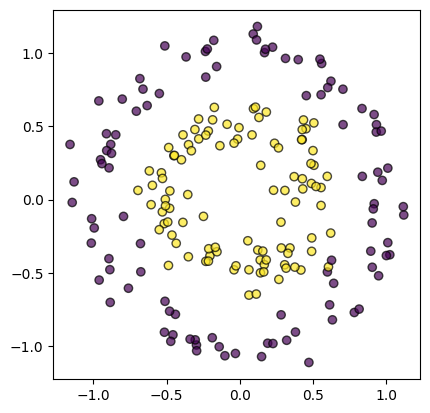

In [303]:
# Generate data

X, y = make_circles(
    n_samples=200,
    factor=0.5,
    noise=0.1,
    random_state=42,
)
y = 2 * y - 1 # y -> {-1, 1}

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', alpha=0.7)
plt.gca().set_aspect('equal')
plt.show()

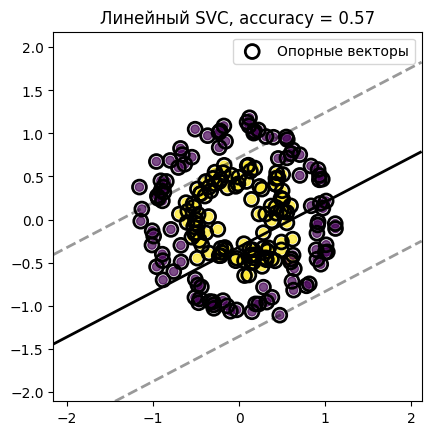

In [304]:
linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', C=1))
])
linear_pipe.fit(X, y)
acc_linear = linear_pipe.score(X, y)

fig, ax = plt.subplots(1, 1)
ax.scatter(X[:, 0], X[:, 1], c=y, alpha=0.7)
plot_linear_svc_decision_boundaries(linear_pipe.named_steps['svc'], X, y,
    scaler=linear_pipe.named_steps['scaler'], ax=ax)
ax.set_title(f'Линейный SVC, accuracy = {acc_linear:.2f}')
plt.show()

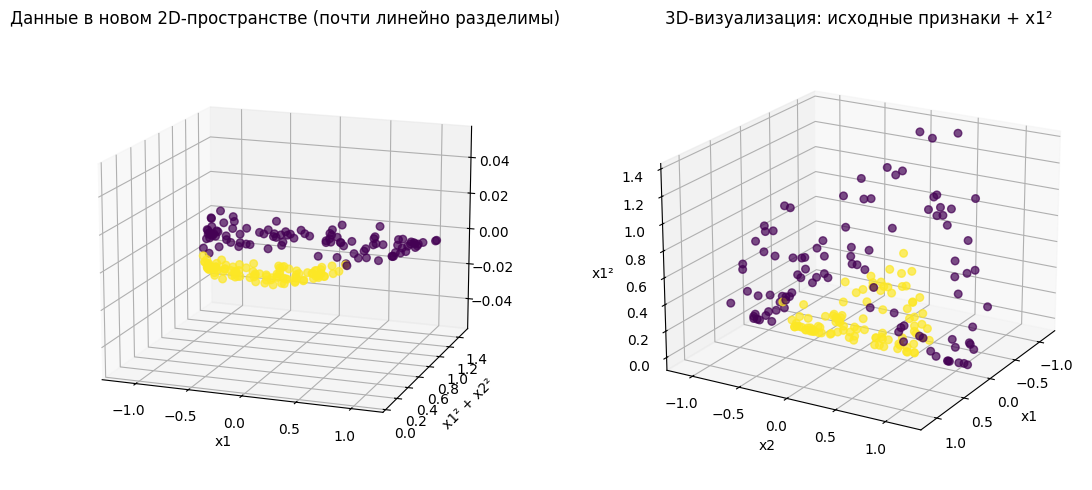

In [305]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)  # теперь [x1, x2, x1^2, x1*x2, x2^2]

# Для визуализации возьмём только два "полезных" признака: x1 и x1^2 + x2^2
X_3d = np.column_stack([X[:, 0], X[:, 0]**2 + X[:, 1]**2])

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_3d[:, 0], X_3d[:, 1], np.zeros_like(X_3d[:, 0]), c=y, s=30, alpha=0.7)
ax1.set_xlabel('x1')
ax1.set_ylabel('x1² + x2²')
ax1.set_title('Данные в новом 2D-пространстве (почти линейно разделимы)')
ax1.view_init(elev=15, azim=-70)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_poly[:, 0], X_poly[:, 1], X_poly[:, 2], c=y, s=30, alpha=0.7)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('x1²')
ax2.set_title('3D-визуализация: исходные признаки + x1²')
ax2.view_init(elev=20, azim=30)

plt.tight_layout()
plt.show()

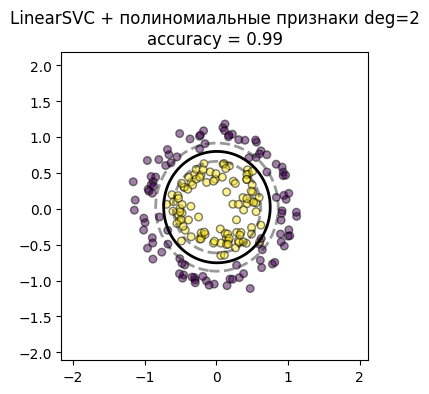

In [306]:
poly_svc_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(C=1, random_state=42, max_iter=10000))
])
poly_svc_pipe.fit(X, y)
acc_poly_features = poly_svc_pipe.score(X, y)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_linear_svc_decision_boundaries(poly_svc_pipe, X, y, scaler=None, ax=ax)
ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors='k', alpha=0.5)
ax.set_title(f'LinearSVC + полиномиальные признаки deg=2\naccuracy = {acc_poly_features:.2f}')
ax.set_aspect('equal')
plt.show()

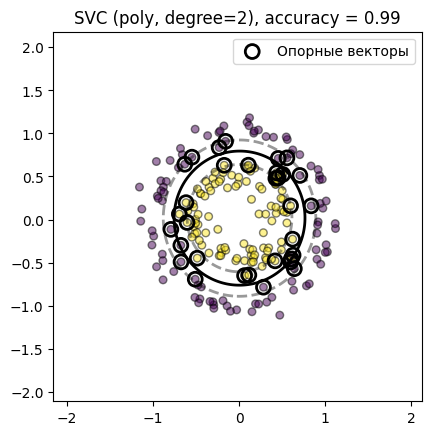

In [307]:
poly_kernel_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='poly', degree=2, C=1, gamma='scale', random_state=42))
])
poly_kernel_pipe.fit(X, y)
acc_poly_kernel = poly_kernel_pipe.score(X, y)

fig, ax = plt.subplots(1, 1)
ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors='k', alpha=0.5)
plot_linear_svc_decision_boundaries(poly_kernel_pipe.named_steps['svc'], X, y,
                  scaler=poly_kernel_pipe.named_steps['scaler'], ax=ax)
ax.set_title(f'SVC (poly, degree=2), accuracy = {acc_poly_kernel:.2f}')
ax.set_aspect('equal')
plt.show()

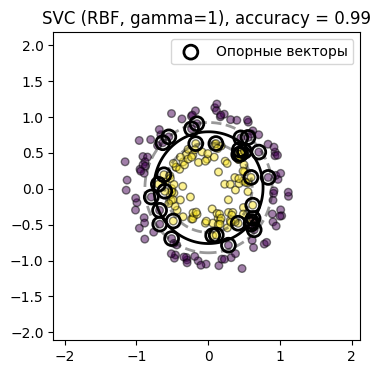

In [308]:
rbf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', gamma=1, C=1, random_state=42))
])
rbf_pipe.fit(X, y)
acc_rbf = rbf_pipe.score(X, y)
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors='k', alpha=0.5)
plot_linear_svc_decision_boundaries(poly_kernel_pipe.named_steps['svc'], X, y,
                  scaler=rbf_pipe.named_steps['scaler'], ax=ax)
ax.set_title(f'SVC (RBF, gamma=1), accuracy = {acc_rbf:.2f}')
plt.show()

In [310]:
print(f"{'Модель':<40} {'Accuracy':<10} {'#SV':<10}")
print("-" * 60)
print(f"{'Linear SVC (исходные признаки)':<40} {acc_linear:<10.3f} "
      f"{len(linear_pipe.named_steps['svc'].support_vectors_):<10}")
print(f"{'LinearSVC + полиномиальные признаки deg=2':<40} {acc_poly_features:<10.3f} "
      f"{'n/a':<10}")  # LinearSVC не хранит SV
print(f"{'SVC (poly, degree=2)':<40} {acc_poly_kernel:<10.3f} "
      f"{len(poly_kernel_pipe.named_steps['svc'].support_vectors_):<10}")
print(f"{'SVC (RBF, gamma=1)':<40} {acc_rbf:<10.3f} "
      f"{len(rbf_pipe.named_steps['svc'].support_vectors_):<10}")


Модель                                   Accuracy   #SV       
------------------------------------------------------------
Linear SVC (исходные признаки)           0.575      200       
LinearSVC + полиномиальные признаки deg=2 0.995      n/a       
SVC (poly, degree=2)                     0.990      32        
SVC (RBF, gamma=1)                       0.995      48        


## Масштабирование признаков

In [311]:
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2.0)
y = 2 * y - 1  # метки -1, 1

X_scaled = X.copy()
X_scaled[:, 1] = X_scaled[:, 1] * 1000


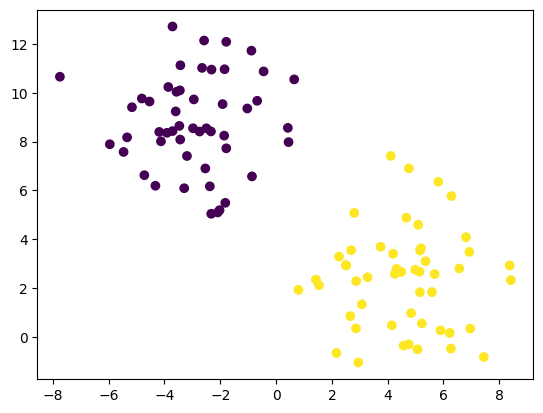

In [312]:
plt.scatter(X[:, 0], X[:, 1], c=y)

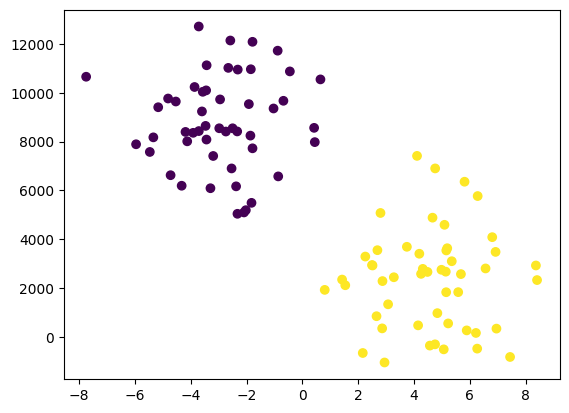

In [313]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)

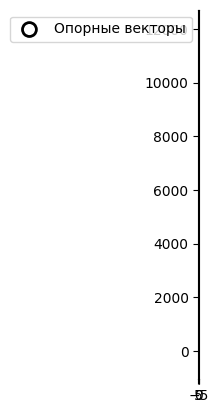

In [314]:
classifier = SVC(kernel='rbf', gamma='scale', C=1, random_state=42)
classifier.fit(X_scaled, y)
acc_no_scaler = classifier.score(X_scaled, y)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plot_linear_svc_decision_boundaries(classifier, X_scaled, y, scaler=None, ax=plt.gca())
plt.show()

In [315]:
svc_linear_no_scaler = SVC(kernel='linear', C=1, random_state=42)
svc_linear_no_scaler.fit(X_scaled, y)
print("Линейный SVC без масштабирования:")
print(f"  Коэффициенты: {svc_linear_no_scaler.coef_[0]}")
print(f"  Свободный член: {svc_linear_no_scaler.intercept_[0]:.2f}")
print(f"  Количество опорных векторов: {len(svc_linear_no_scaler.support_vectors_)}")

Линейный SVC без масштабирования:
  Коэффициенты: [ 4.84052051e-01 -3.06514225e-04]
  Свободный член: 1.17
  Количество опорных векторов: 4


## Hyperparameters tuning

In [316]:
digits = load_digits()
X, y = digits.data, digits.target

# laeve only 4 and 9 for binary classification
mask = (y == 4) | (y == 9)
X_bin = X[mask]
y_bin = y[mask]
y_bin = 2 * (y_bin == 9) - 1

print(f"Размер выборки: {X_bin.shape}")
print(f"Классы: {np.unique(y_bin)} (4 -> -1, 9 -> +1)")

Размер выборки: (361, 64)
Классы: [-1  1] (4 -> -1, 9 -> +1)


In [317]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
])

param_grid = {
    'svc__C': [0.1, 1, 10, 100],          # регуляризация
    'svc__gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto']  # параметр RBF
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'svc__C': [0.1, 1, 10, 100],
                         'svc__gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto']},
             return_train_score=True, scoring='accuracy', verbose=1)

In [318]:
print("\nЛучшие параметры:", grid_search.best_params_)
print("Лучшая точность на кросс-валидации: {:.4f}".format(grid_search.best_score_))


Лучшие параметры: {'svc__C': 100, 'svc__gamma': 0.001}
Лучшая точность на кросс-валидации: 1.0000


Точность на тесте: 1.0000


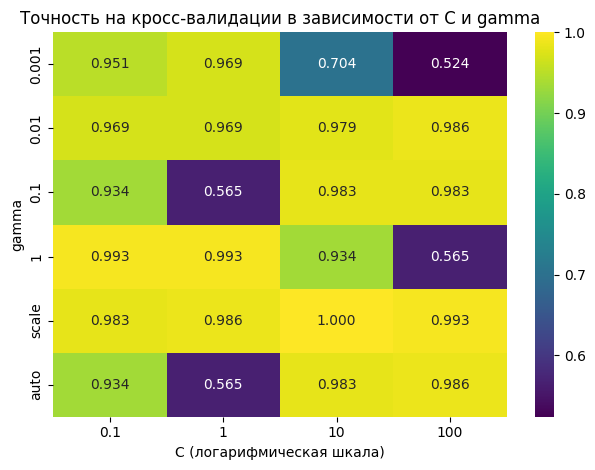

In [319]:
y_pred = grid_search.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("Точность на тесте: {:.4f}".format(test_acc))

results = grid_search.cv_results_
C_values = param_grid['svc__C']
gamma_values = param_grid['svc__gamma']

mean_test_scores = results['mean_test_score'].reshape(len(gamma_values), len(C_values))

sns.heatmap(mean_test_scores,
            xticklabels=C_values,
            yticklabels=gamma_values,
            annot=True, fmt='.3f', cmap='viridis')
plt.xlabel('C (логарифмическая шкала)')
plt.ylabel('gamma')
plt.title('Точность на кросс-валидации в зависимости от C и gamma')
plt.tight_layout()
plt.show()

## NuSVM

In [320]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print(f"Размер данных: {X.shape}")
print(f"Распределение классов: {np.bincount(y)} (0: злокач., 1: доброкач.)")

Размер данных: (569, 30)
Распределение классов: [212 357] (0: злокач., 1: доброкач.)


In [321]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('nusvc', NuSVC(kernel='rbf', gamma='scale', nu=0.5, random_state=42))
])

In [322]:
base_pipe.fit(X_train, y_train)
y_pred_base = base_pipe.predict(X_test)

print("=== Базовая модель (nu=0.5) ===")
print(f"Точность на тесте: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Доля опорных векторов: {len(base_pipe.named_steps['nusvc'].support_vectors_) / len(X_train):.4f}")
print(f"Число опорных векторов: {len(base_pipe.named_steps['nusvc'].support_vectors_)}")

=== Базовая модель (nu=0.5) ===
Точность на тесте: 0.9386
Доля опорных векторов: 0.5187
Число опорных векторов: 236


In [323]:
nu_values = [0.01, 0.05, 0.1, 0.2, 0.5, 0.7]
train_errors = []
sv_fractions = []

for nu in nu_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('nusvc', NuSVC(kernel='rbf', gamma='scale', nu=nu, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    y_train_pred = pipe.predict(X_train)
    # Доля ошибок на обучении
    err = 1 - accuracy_score(y_train, y_train_pred)
    train_errors.append(err)
    sv_frac = len(pipe.named_steps['nusvc'].support_vectors_) / len(X_train)
    sv_fractions.append(sv_frac)
    print(f"nu={nu:.2f}: train_error={err:.4f} (≤{nu:.2f}? {err <= nu}), SV fraction={sv_frac:.4f} (≥{nu:.2f}? {sv_frac >= nu})")


nu=0.01: train_error=0.0000 (≤0.01? True), SV fraction=0.1429 (≥0.01? True)
nu=0.05: train_error=0.0066 (≤0.05? True), SV fraction=0.1846 (≥0.05? True)
nu=0.10: train_error=0.0132 (≤0.10? True), SV fraction=0.1846 (≥0.10? True)
nu=0.20: train_error=0.0176 (≤0.20? True), SV fraction=0.2549 (≥0.20? True)
nu=0.50: train_error=0.0505 (≤0.50? True), SV fraction=0.5187 (≥0.50? True)
nu=0.70: train_error=0.0505 (≤0.70? True), SV fraction=0.7055 (≥0.70? True)


In [324]:
param_grid = {
    'nusvc__nu': np.linspace(0.01, 0.3, 20),
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('nusvc', NuSVC(kernel='rbf', random_state=42, gamma='scale'))
])

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=StratifiedKFold(5),
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n=== Лучшие параметры ===")
print(f"Лучший recall (класс 0): {grid.best_score_:.4f}")
print(f"Параметры: {grid.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Лучшие параметры ===
Лучший recall (класс 0): 0.9860
Параметры: {'nusvc__nu': np.float64(0.3)}


In [325]:
best_nu = grid.best_params_['nusvc__nu']
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('nusvc', NuSVC(kernel='rbf', gamma='scale', nu=best_nu, random_state=42))
])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
test_recall = recall_score(y_test, y_pred, pos_label=0)  # recall по злокачественным
print(f"Recall на тесте по классу 0: {test_recall:.4f}")

Recall на тесте по классу 0: 0.9286
